# K-近邻算法
## 什么是K-近邻算法

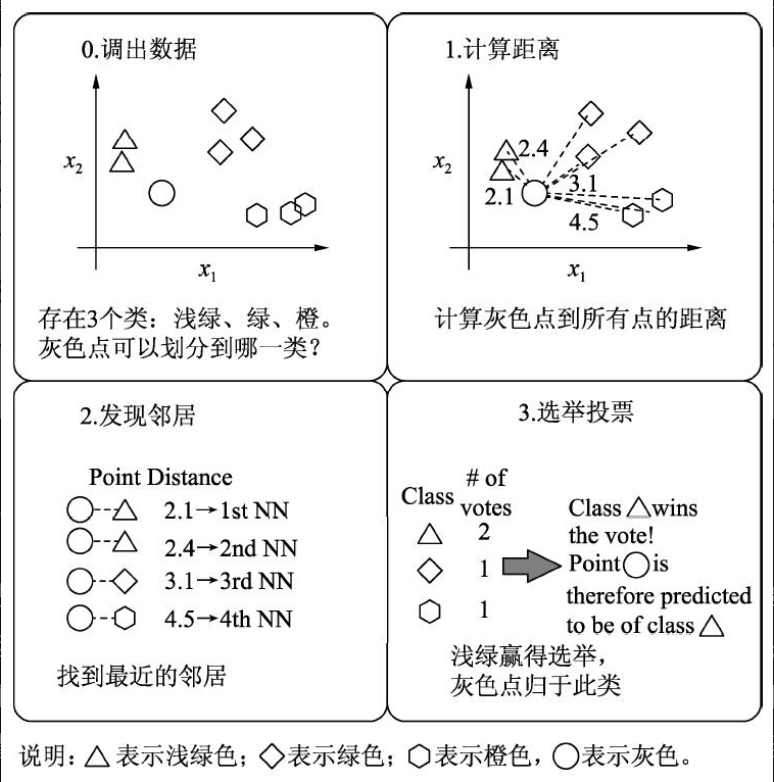

**“邻居”来推断出你的类别**

### 定义
如果一个样本在特征空间中的k个最相似(即特征空间中最邻近)的样本中的大多数属于某一个类别，则该样本也属于这个类别。

### KNN 算法核心思路
𝑘近邻法（k-Nearest Neighbor,kNN）是一种比较成熟也是最简单的机器学习算法，可以用于基本的分类与回归方法。

如果一个样本在特征空间中与𝑘个实例最为相似(即特征空间中最邻近)，那么这𝑘个实例中大多数属于哪个类别，则该样本也属于这个类别。

- 对于分类问题：对新的样本，根据其𝑘个最近邻的训练样本的类别，通过多数表决等方式进行预测。
- 对于回归问题：对新的样本，根据其𝑘个最近邻的训练样本标签值的均值作为预测值。

### 𝑘近邻法的三要素
- 𝑘值选择。
- 距离度量。
- 决策规则。

### 算法流程
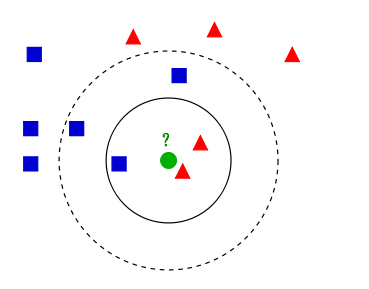
**1.**计算测试对象到训练集中每个对象的距离

**2.**按照距离的远近排序

**3.**选取与当前测试对象最近的k的训练对象，作为该测试对象的邻居

**4.**统计这k个邻居的类别频次

**5.**k个邻居里频次最高的类别，即为测试对象的类别

### 距离公式
两个样本的距离可以通过如下公式计算，又叫欧式距离

欧几里得度量（Euclidean Metric）（也称欧氏距离）是一个通常采用的距离定义，指在𝑚维空间中两个点之间的真实距离，或者向量的自然长度（即该点到原点的距离）。在二维和三维空间中的欧氏距离就是两点之间的实际距离。

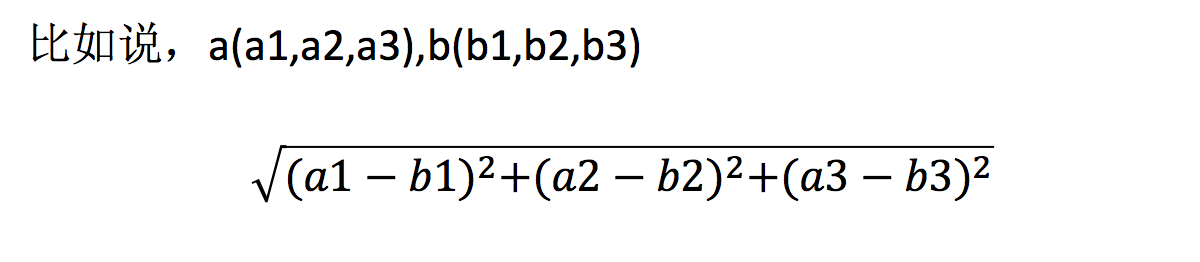

## 电影类型分析
假设我们有现在几部电影：
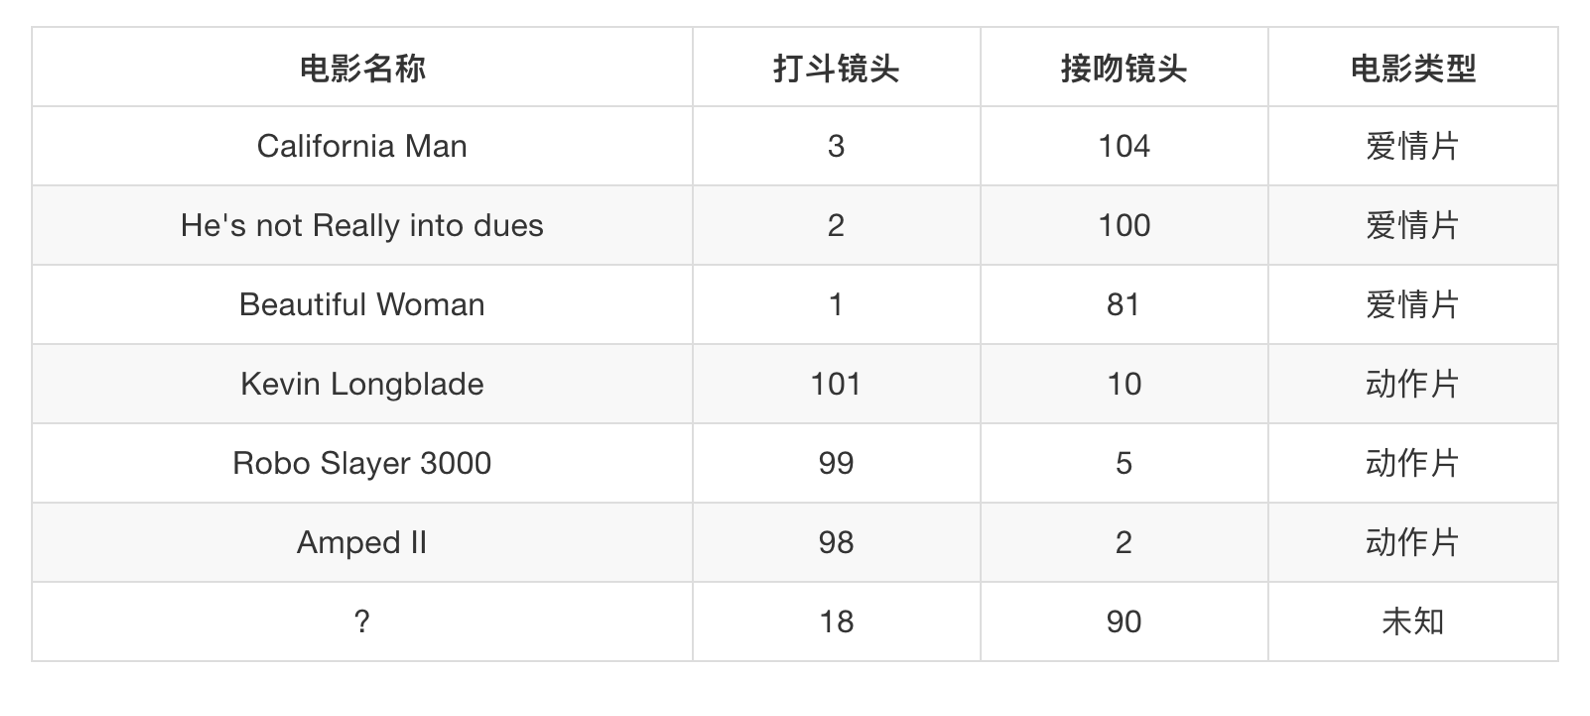

其中？ 号电影不知道类别，如何去预测？我们可以利用K近邻算法的思想
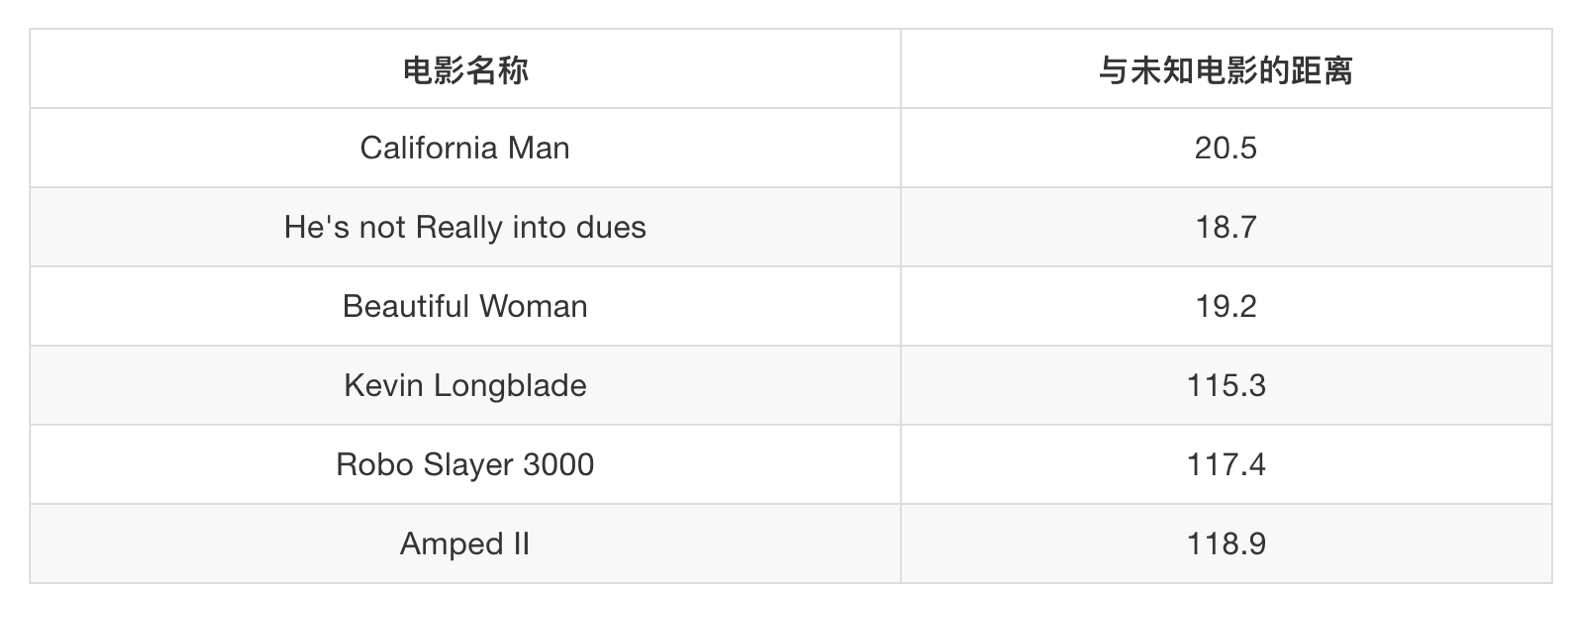
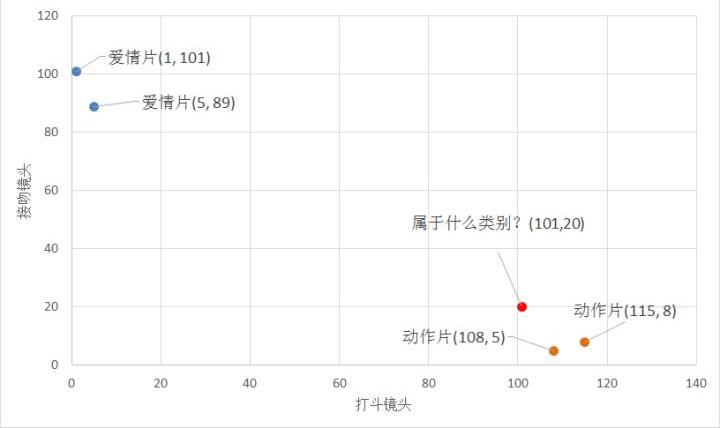

**思考：如果取的最近的电影数量不一样？会是什么结果？**

## K-近邻算法API

- sklearn.neighbors.KNeighborsClassifier(n_neighbors=5,algorithm='auto')
    - n_neighbors：int,可选（默认= 5），k_neighbors查询默认使用的邻居数
    - algorithm：{‘auto’，‘ball_tree’，‘kd_tree’，‘brute’}，可选用于计算最近邻居的算法：‘ball_tree’将会使用 BallTree，‘kd_tree’将使用 KDTree。‘auto’将尝试根据传递给fit方法的值来决定最合适的算法。 (不同实现方式影响效率)

In [14]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier  # K近邻算法

# 定义电影数据集
movies = [
    {"features": (3, 104), "label": "爱情片"},
    {"features": (2, 100), "label": "爱情片"},
    {"features": (1, 81), "label": "爱情片"},
    {"features": (101, 10), "label": "动作片"},
    {"features": (99, 5), "label": "动作片"},
    {"features": (98, 2), "label": "动作片"},
]

# Pandas 格式
movies_df = pd.DataFrame(movies)

# 2. 处理特征格式：将元组列表转为二维数组（sklearn要求）
X = np.array(movies_df["features"].tolist())  # 特征矩阵：6行2列
print(X)
y = movies_df["label"]  # 标签数组
print(y)

# 新电影的特征（需转为二维数组）
new_movie = np.array([[18, 90]])  # 注意：必须是二维，形状(1,2)

# 3. 初始化并训练KNN模型
knn = KNeighborsClassifier(n_neighbors=3, algorithm='auto')  # K值选3更合理（样本共6个）
knn.fit(X, y)  # 传入二维特征矩阵和一维标签  (训练)

# 4. 预测新电影类型
predicted_label = knn.predict(new_movie)
print(f"新电影的预测类型是: {predicted_label[0]}")  # predicted_label是数组，取第一个元素

[[  3 104]
 [  2 100]
 [  1  81]
 [101  10]
 [ 99   5]
 [ 98   2]]
0    爱情片
1    爱情片
2    爱情片
3    动作片
4    动作片
5    动作片
Name: label, dtype: object
新电影的预测类型是: 爱情片


### 案例：预测签到位置
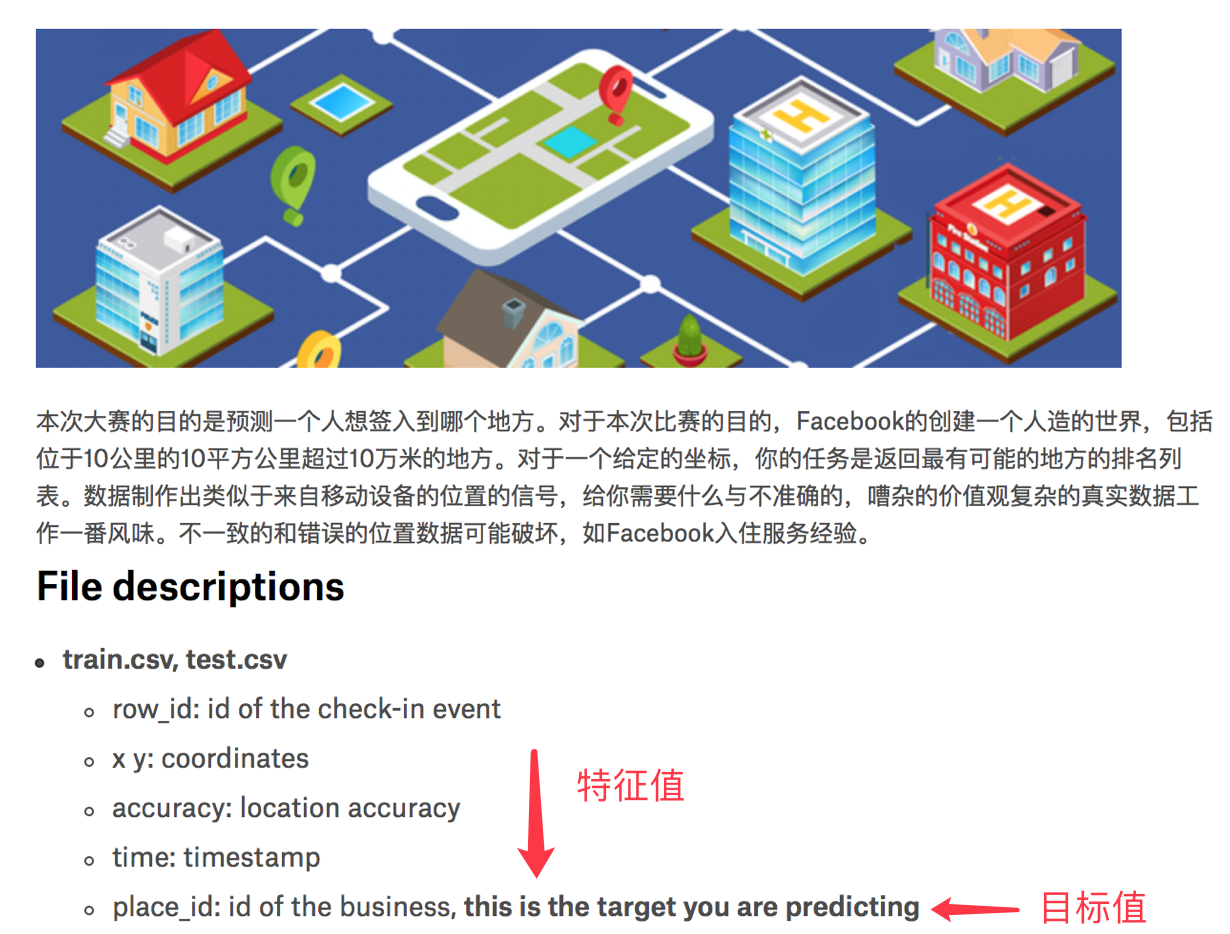

数据介绍：将根据用户的位置，准确性和时间戳预测用户正在查看的业务。
```
train.csv，test.csv 
row_id：登记事件的ID
xy：坐标
准确性：定位准确性 
时间：时间戳
place_id：业务的ID，这是您预测的目标



官网：https://www.kaggle.com/navoshta/grid-knn/data
```

### 分析
- 对于数据做一些基本处理（这里所做的一些处理不一定达到很好的效果，我们只是简单尝试，有些特征我们可以根据一些特征选择的方式去做处理）

    - 1、缩小数据集范围 DataFrame.query()

    - 2、删除没用的日期数据 DataFrame.drop（可以选择保留）

    - 3、将签到位置少于n个用户的删除

        place_count = data.groupby('place_id').count()

        tf = place_count[place_count.row_id > 3].reset_index()

        data = data[data['place_id'].isin(tf.place_id)]
        

- 分割数据集

- 标准化处理

- k-近邻预测

### 代码实现

In [24]:
import pandas as pd  # 用于数据处理
from sklearn.model_selection import train_test_split  # 用于数据分割
from sklearn.preprocessing import StandardScaler  # 用于数据标准化
from sklearn.neighbors import KNeighborsClassifier  # K近邻算法

def knncls():
    """
    K近邻算法预测入住位置类别
    :return:
    """
    # 一、处理数据以及特征工程
    # 1、读取收，缩小数据的范围
    data = pd.read_csv("train.csv")

    # 数据逻辑筛选操作 df.query()
    data = data.query("x > 1.0 & x < 1.25 & y > 2.5 & y < 2.75")

    # 删除time这一列特征
    data = data.drop(['time'], axis=1)

    print(data)

    # 删除入住次数少于三次位置
    place_count = data.groupby('place_id').count()

    tf = place_count[place_count.row_id > 3].reset_index()

    data = data[data['place_id'].isin(tf.place_id)]

    # 3、取出特征值和目标值
    y = data['place_id']
    # y = data[['place_id']]

    x = data.drop(['place_id', 'row_id'], axis=1)

    # 4、数据分割与特征工程?

    # （1）、数据分割
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

    # (2)、标准化
    std = StandardScaler()

    # 队训练集进行标准化操作
    x_train = std.fit_transform(x_train)
    print(x_train)

    # 进行测试集的标准化操作
    x_test = std.transform(x_test)

    # 二、算法的输入训练预测
    # K值：算法传入参数不定的值    理论上：k = 根号(样本数)
    # K值：后面会使用参数调优方法，去轮流试出最好的参数[1,3,5,10,20,100,200]
    knn = KNeighborsClassifier(n_neighbors=10)

    # 调用fit()
    knn.fit(x_train, y_train)

    # 预测测试数据集，得出准确率
    y_predict = knn.predict(x_test)

    print("预测测试集类别：", y_predict)

    print("准确率为：", knn.score(x_test, y_test))

    return None

In [25]:
knncls()

            row_id       x       y  accuracy    place_id
600            600  1.2214  2.7023        17  6683426742
957            957  1.1832  2.6891        58  6683426742
4345          4345  1.1935  2.6550        11  6889790653
4735          4735  1.1452  2.6074        49  6822359752
5580          5580  1.0089  2.7287        19  1527921905
...            ...     ...     ...       ...         ...
29100203  29100203  1.0129  2.6775        12  3312463746
29108443  29108443  1.1474  2.6840        36  3533177779
29109993  29109993  1.0240  2.7238        62  6424972551
29111539  29111539  1.2032  2.6796        87  3533177779
29112154  29112154  1.1070  2.5419       178  4932578245

[17710 rows x 5 columns]
[[ 1.54435396  1.2566276   6.57889205]
 [ 1.04739022  0.93384714 -0.49252109]
 [-0.53902128 -1.16781231  1.62980597]
 ...
 [-1.04889316  0.47334702 -0.08611803]
 [ 0.34389611  0.53646853 -0.20352336]
 [ 1.5830784   1.31831453 -0.70926938]]
预测测试集类别： [3322359335 1097200869 8048985799 ... 503